In [ ]:
# Cell 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
print("Google Drive Mounted Successfully!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive Mounted Successfully!


In [ ]:
# Cell 2: Import Libraries
import os
import shutil
import itertools
import warnings
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout, BatchNormalization
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing import image
from sklearn.metrics import confusion_matrix, classification_report

warnings.filterwarnings("ignore")
print('Modules loaded')

Modules loaded


In [ ]:
# Cell 3: Check TensorFlow Version
print(tf.__version__)

2.19.0


In [ ]:
# Cell 4: Define Paths and Copy Data
# 1. Define Source Paths (on Google Drive)
# This path is the file system path AFTER mounting your drive
base_drive_path = '/content/drive/MyDrive/dataset'

# --- These paths should now be correct ---
drive_train_path = os.path.join(base_drive_path, 'train')
drive_valid_path = os.path.join(base_drive_path, 'val')
drive_test_path = os.path.join(base_drive_path, 'test')

# 2. Define Destination Paths (on local Colab runtime for speed)
local_data_path = '/content/dataset'
local_train_path = os.path.join(local_data_path, 'train')
local_valid_path = os.path.join(local_data_path, 'val')
local_test_path = os.path.join(local_data_path, 'test')

# 3. Copy data from Drive to local runtime for faster I/O
# This will take a few minutes but dramatically speeds up training
print("Copying training data...")
shutil.copytree(drive_train_path, local_train_path)
print("Copying validation data...")
shutil.copytree(drive_valid_path, local_valid_path)
print("Copying test data...")
shutil.copytree(drive_test_path, local_test_path)
print("Data copy complete.")

Copying training data...
Copying validation data...
Copying test data...
Data copy complete.


In [ ]:
# Cell 5: Create Image Data Generators
img_size = (224, 224)
batch_size = 16
channels = 3
img_shape = (img_size[0], img_size[1], channels)

def scalar(img):
    return preprocess_input(img)

# Training generator with augmentation
tr_gen = ImageDataGenerator(preprocessing_function=scalar, horizontal_flip=True)

# Validation & Test generator (no augmentation)
ts_gen = ImageDataGenerator(preprocessing_function=scalar)

train_gen = tr_gen.flow_from_directory(
    local_train_path,
    target_size=img_size,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=True,
    batch_size=batch_size
)

valid_gen = ts_gen.flow_from_directory(
    local_valid_path,
    target_size=img_size,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False,
    batch_size=batch_size
)

test_gen = ts_gen.flow_from_directory(
    local_test_path,
    target_size=img_size,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False,
    batch_size=batch_size
)

Found 4946 images belonging to 2 classes.
Found 120 images belonging to 2 classes.
Found 126 images belonging to 2 classes.


In [ ]:
# Cell 6: Show a Batch of Images
g_dict = train_gen.class_indices
classes = list(g_dict.keys())
train_gen.reset()
images, labels = next(train_gen)

plt.figure(figsize=(20, 20))

for i in range(16):
    plt.subplot(4, 4, i + 1)
    # De-normalize image for display
    image_display = (images[i] - images[i].min()) / (images[i].max() - images[i].min())
    image_display = np.clip(image_display, 0, 1)
    plt.imshow(image_display)
    index = np.argmax(labels[i])
    class_name = classes[index]
    plt.title(class_name, color='blue', fontsize=12)
    plt.axis('off')

plt.show()

In [ ]:
# Cell 7: Create Model (EfficientNetB3)
class_count = len(list(train_gen.class_indices.keys()))

base_model = tf.keras.applications.EfficientNetB3(
    include_top=False,
    weights="imagenet",
    input_shape=img_shape,
    pooling='max'
)

efficentNet_model = Sequential([
    base_model,
    BatchNormalization(axis=-1, momentum=0.99, epsilon=0.001),
    # --- THIS BLOCK IS FIXED ---
    Dense(256, kernel_regularizer=regularizers.l2(l2=0.016),
          activity_regularizer=regularizers.l1(l1=0.006),
          bias_regularizer=regularizers.l1(l1=0.006),
          activation='relu'),
    # --- END OF FIX ---
    Dropout(rate=0.45, seed=123),
    Dense(class_count, activation='softmax')
])

efficentNet_model.compile(Adamax(learning_rate=0.001),
                        loss='categorical_crossentropy',
                        metrics=['accuracy'])

efficentNet_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb3 (Functional)     │ (None, 1536)           │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1536)           │         6,144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       393,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,183,665 (42.66 MB)

 Trainable params: 11,093,290 (42.32 MB)

 Non-trainable params: 90,375 (353.03 KB)

In [ ]:
# Cell 8: Define Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    mode='min'
)

model_checkpoint = ModelCheckpoint(
    filepath='/content/best_model_EfficientNet.h5',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

callbacks = [early_stopping, model_checkpoint]

In [ ]:
# Cell 9: Train the Model
epochs = 100

history = efficentNet_model.fit(
    x=train_gen,
    epochs=epochs,
    verbose=1,
    validation_data=valid_gen,
    callbacks=callbacks,
    shuffle=False
)

# Load best weights saved by ModelCheckpoint
efficentNet_model.load_weights('/content/best_model_EfficientNet.h5')

Epoch 1/100
310/310 ━━━━━━━━━━━━━━━━━━━━ 0s 463ms/step - accuracy: 0.6105 - loss: 10.7505
Epoch 1: val_loss improved from inf to 4.85940, saving model to /content/best_model_EfficientNet.h5


310/310 ━━━━━━━━━━━━━━━━━━━━ 305s 582ms/step - accuracy: 0.6103 - loss: 10.7395 - val_accuracy: 0.7417 - val_loss: 4.8594
Epoch 2/100
310/310 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.5282 - loss: 4.3812
Epoch 2: val_loss improved from 4.85940 to 3.15023, saving model to /content/best_model_EfficientNet.h5


310/310 ━━━━━━━━━━━━━━━━━━━━ 78s 252ms/step - accuracy: 0.5281 - loss: 4.3798 - val_accuracy: 0.7667 - val_loss: 3.1502
Epoch 3/100
310/310 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.5258 - loss: 2.8997
Epoch 3: val_loss improved from 3.15023 to 2.16095, saving model to /content/best_model_EfficientNet.h5


310/310 ━━━━━━━━━━━━━━━━━━━━ 76s 246ms/step - accuracy: 0.5258 - loss: 2.8989 - val_accuracy: 0.7667 - val_loss: 2.1610
Epoch 4/100
309/310 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.5229 - loss: 2.0113
Epoch 4: val_loss improved from 2.16095 to 1.57243, saving model to /content/best_model_EfficientNet.h5


310/310 ━━━━━━━━━━━━━━━━━━━━ 81s 260ms/step - accuracy: 0.5229 - loss: 2.0104 - val_accuracy: 0.7667 - val_loss: 1.5724
Epoch 5/100
309/310 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.5213 - loss: 1.4973
Epoch 5: val_loss improved from 1.57243 to 1.21709, saving model to /content/best_model_EfficientNet.h5


...

310/310 ━━━━━━━━━━━━━━━━━━━━ 76s 246ms/step - accuracy: 0.7784 - loss: 0.4187 - val_accuracy: 0.8667 - val_loss: 0.4051
Epoch 48/100
309/310 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - accuracy: 0.7633 - loss: 0.4201
Epoch 48: val_loss did not improve from 0.40506
310/310 ━━━━━━━━━━━━━━━━━━━━ 75s 243ms/step - accuracy: 0.7634 - loss: 0.4201 - val_accuracy: 0.8667 - val_loss: 0.4301
Epoch 49/100
309/310 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - accuracy: 0.7776 - loss: 0.4109
Epoch 49: val_loss did not improve from 0.40506
310/310 ━━━━━━━━━━━━━━━━━━━━ 75s 241ms/step - accuracy: 0.7776 - loss: 0.4109 - val_accuracy: 0.8750 - val_loss: 0.4388
Epoch 50/100
310/310 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - accuracy: 0.7898 - loss: 0.4097
Epoch 50: val_loss did not improve from 0.40506
310/310 ━━━━━━━━━━━━━━━━━━━━ 73s 236ms/step - accuracy: 0.7898 - loss: 0.4097 - val_accuracy: 0.8917 - val_loss: 0.4053
Epoch 51/100
309/310 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - accuracy: 0.7752 - loss: 0.4056
Epoch 51: val_lo

310/310 ━━━━━━━━━━━━━━━━━━━━ 80s 257ms/step - accuracy: 0.7752 - loss: 0.4056 - val_accuracy: 0.9083 - val_loss: 0.3922
Epoch 52/100
309/310 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - accuracy: 0.7775 - loss: 0.4081
Epoch 52: val_loss improved from 0.39219 to 0.38219, saving model to /content/best_model_EfficientNet.h5


310/310 ━━━━━━━━━━━━━━━━━━━━ 76s 244ms/step - accuracy: 0.7775 - loss: 0.4080 - val_accuracy: 0.8917 - val_loss: 0.3822
Epoch 53/100
310/310 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - accuracy: 0.7737 - loss: 0.3969
Epoch 53: val_loss did not improve from 0.38219
310/310 ━━━━━━━━━━━━━━━━━━━━ 74s 238ms/step - accuracy: 0.7737 - loss: 0.3970 - val_accuracy: 0.8833 - val_loss: 0.3929
Epoch 54/100
309/310 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - accuracy: 0.7673 - loss: 0.4126
Epoch 54: val_loss did not improve from 0.38219
310/310 ━━━━━━━━━━━━━━━━━━━━ 74s 239ms/step - accuracy: 0.7673 - loss: 0.4126 - val_accuracy: 0.8667 - val_loss: 0.4073
Epoch 55/100
310/310 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.7811 - loss: 0.4028
Epoch 55: val_loss did not improve from 0.38219
310/310 ━━━━━━━━━━━━━━━━━━━━ 75s 241ms/step - accuracy: 0.7811 - loss: 0.4028 - val_accuracy: 0.8583 - val_loss: 0.3951
Epoch 56/100
309/310 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.7755 - loss: 0.4085
Epoch 56: val_lo

310/310 ━━━━━━━━━━━━━━━━━━━━ 76s 244ms/step - accuracy: 0.7800 - loss: 0.3834 - val_accuracy: 0.9167 - val_loss: 0.3662
Epoch 60/100
309/310 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - accuracy: 0.7687 - loss: 0.4091
Epoch 60: val_loss did not improve from 0.36615
310/310 ━━━━━━━━━━━━━━━━━━━━ 74s 238ms/step - accuracy: 0.7688 - loss: 0.4090 - val_accuracy: 0.8833 - val_loss: 0.3963
Epoch 61/100
310/310 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - accuracy: 0.7680 - loss: 0.4004
Epoch 61: val_loss did not improve from 0.36615
310/310 ━━━━━━━━━━━━━━━━━━━━ 73s 236ms/step - accuracy: 0.7680 - loss: 0.4004 - val_accuracy: 0.8667 - val_loss: 0.3984
Epoch 62/100
309/310 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - accuracy: 0.7870 - loss: 0.3990
Epoch 62: val_loss did not improve from 0.36615
310/310 ━━━━━━━━━━━━━━━━━━━━ 73s 237ms/step - accuracy: 0.7869 - loss: 0.3989 - val_accuracy: 0.8833 - val_loss: 0.3858
Epoch 63/100
309/310 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - accuracy: 0.7828 - loss: 0.3794
Epoch 63: val_lo

310/310 ━━━━━━━━━━━━━━━━━━━━ 75s 241ms/step - accuracy: 0.7708 - loss: 0.3947 - val_accuracy: 0.9167 - val_loss: 0.3506
Epoch 65/100
310/310 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - accuracy: 0.7728 - loss: 0.4039
Epoch 65: val_loss did not improve from 0.35055
310/310 ━━━━━━━━━━━━━━━━━━━━ 80s 258ms/step - accuracy: 0.7727 - loss: 0.4039 - val_accuracy: 0.8917 - val_loss: 0.3884
Epoch 66/100
309/310 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.7860 - loss: 0.4025
Epoch 66: val_loss did not improve from 0.35055
310/310 ━━━━━━━━━━━━━━━━━━━━ 80s 256ms/step - accuracy: 0.7860 - loss: 0.4024 - val_accuracy: 0.8917 - val_loss: 0.3663
Epoch 67/100
309/310 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - accuracy: 0.7790 - loss: 0.4004
Epoch 67: val_loss did not improve from 0.35055
310/310 ━━━━━━━━━━━━━━━━━━━━ 74s 238ms/step - accuracy: 0.7789 - loss: 0.4004 - val_accuracy: 0.8917 - val_loss: 0.3559
Epoch 68/100
309/310 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - accuracy: 0.7816 - loss: 0.3896
Epoch 68: val_lo

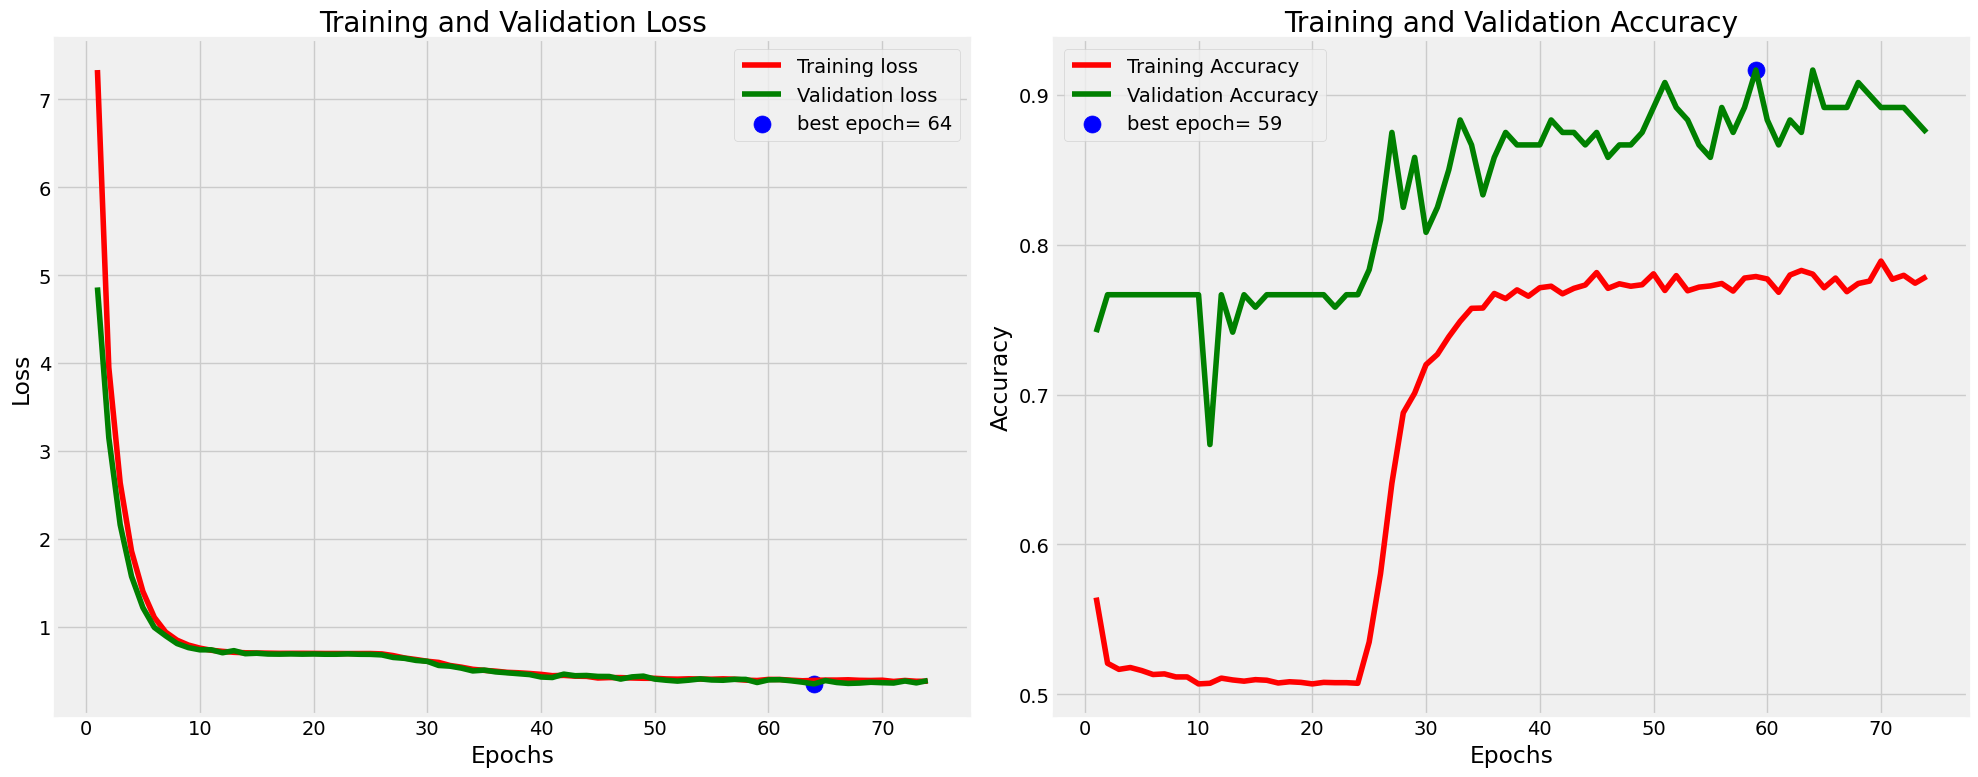

In [ ]:
# Cell 10: Plot Training History
tr_acc = history.history['accuracy']
tr_loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']

index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]
index_acc = np.argmax(val_acc)
acc_highest = val_acc[index_acc]
Epochs = [i+1 for i in range(len(tr_acc))]

loss_label = f'best epoch= {str(index_loss + 1)}'
acc_label = f'best epoch= {str(index_acc + 1)}'

plt.figure(figsize=(20, 8))
plt.style.use('fivethirtyeight')

plt.subplot(1, 2, 1)
plt.plot(Epochs, tr_loss, 'r', label='Training loss')
plt.plot(Epochs, val_loss, 'g', label='Validation loss')
plt.scatter(index_loss + 1, val_lowest, s=150, c='blue', label=loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(Epochs, tr_acc, 'r', label='Training Accuracy')
plt.plot(Epochs, val_acc, 'g', label='Validation Accuracy')
plt.scatter(index_acc + 1, acc_highest, s=150, c='blue', label=acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Cell 11: Evaluate Model
train_gen.reset()
valid_gen.reset()
test_gen.reset()

train_score = efficentNet_model.evaluate(train_gen, verbose=1)
valid_score = efficentNet_model.evaluate(valid_gen, verbose=1)
test_score = efficentNet_model.evaluate(test_gen, verbose=1)

print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Validation Loss: ", valid_score[0])
print("Validation Accuracy: ", valid_score[1])
print('-' * 20)
print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])

310/310 ━━━━━━━━━━━━━━━━━━━━ 69s 224ms/step - accuracy: 0.9955 - loss: 0.2063
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 877ms/step - accuracy: 0.8827 - loss: 0.3985
8/8 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.8741 - loss: 0.3824
Train Loss:  0.20627862215042114
Train Accuracy:  0.995956301689148
--------------------
Validation Loss:  0.35055410861968994
Validation Accuracy:  0.9166666865348816
--------------------
Test Loss:  0.35085099935531616
Test Accuracy:  0.9126983880996704


In [ ]:
# Cell 12: Make Predictions
test_gen.reset()
preds = efficentNet_model.predict(test_gen, verbose=1)
y_pred = np.argmax(preds, axis=1)

8/8 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step


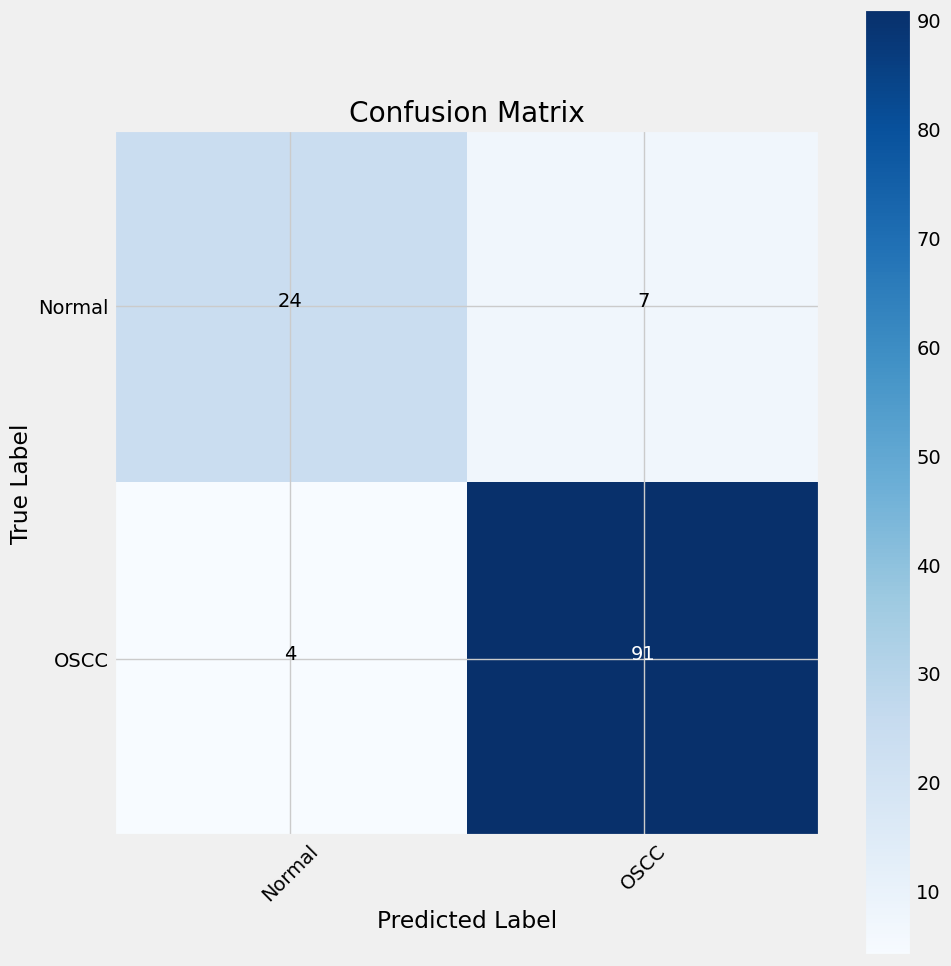

In [ ]:
# Cell 13: Plot Confusion Matrix
g_dict = test_gen.class_indices
classes = list(g_dict.keys())
cm = confusion_matrix(test_gen.classes, y_pred)

plt.figure(figsize=(10, 10))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j], horizontalalignment='center',
             color='white' if cm[i, j] > thresh else 'black')

plt.tight_layout()
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [ ]:
# Cell 14: Classification Report
print(classification_report(test_gen.classes, y_pred, target_names=classes))

              precision    recall  f1-score   support

      Normal       0.86      0.77      0.81        31
        OSCC       0.93      0.96      0.94        95

    accuracy                           0.91       126
   macro avg       0.89      0.87      0.88       126
weighted avg       0.91      0.91      0.91       126



In [ ]:
# Cell 15: Save Final Model
final_model_save_path = '/content/final_efficentnet_model.h5'
efficentNet_model.save(final_model_save_path)
print(f"Final model saved to {final_model_save_path}")

Final model saved to /content/final_efficentnet_model.h5


Test image not found at /content/dataset/test/Normal/aug_356_3394.jpg.


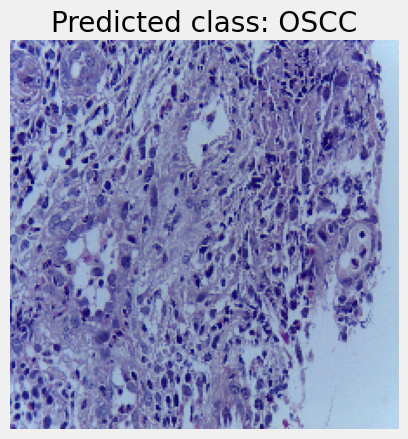

In [ ]:
# Cell 16: Test Predictions on Single Images
def predict_and_display(image_path, model, class_labels):
    img = image.load_img(image_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    prediction = model.predict(img_array, verbose=0)
    predicted_class_index = np.argmax(prediction)
    predicted_class_label = class_labels[predicted_class_index]

    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Predicted class: {predicted_class_label}")
    plt.show()

# Load the best trained model
efficentNet_model.load_weights('/content/best_model_EfficientNet.h5')
class_labels = list(train_gen.class_indices.keys())

# Test Image 1 (from your local 'test/Normal' folder)
image_path_to_test_1 = os.path.join(local_test_path, 'Normal/aug_356_3394.jpg')
if os.path.exists(image_path_to_test_1):
    predict_and_display(image_path_to_test_1, efficentNet_model, class_labels)
else:
    print(f"Test image not found at {image_path_to_test_1}.")

# Test Image 2 (from your local 'test/OSCC' folder)
image_path_to_test_2 = os.path.join(local_test_path, 'OSCC/OSCC_400x_54.jpg')
if os.path.exists(image_path_to_test_2):
    predict_and_display(image_path_to_test_2, efficentNet_model, class_labels)
else:
    print(f"Test image not found at {image_path_to_test_2}.")

In [ ]:
import shutil

# This is the best model saved by your training cell
source_file = '/content/best_model_EfficientNet.h5'

# This is the permanent location on your Google Drive
# You can change the name "my_final_oscc_model.h5" if you want
destination_file = '/content/drive/MyDrive/dataset/my_final_oscc_model.h5'

# Copy the file
try:
    shutil.copy(source_file, destination_file)
    print(f"Model successfully saved to your Google Drive at: {destination_file}")
    print("You can now safely close this notebook!")
except FileNotFoundError:
    print(f"Error: Could not find the source file at {source_file}. Did Cell 9 run correctly?")

Model successfully saved to your Google Drive at: /content/drive/MyDrive/dataset/my_final_oscc_model.h5
You can now safely close this notebook!
